# Proyek Analisis Sentimen Ulasan Play Store (Revisi)

Notebook ini merevisi preprocessing dan pelabelan agar memenuhi kriteria reviewer:
- normalisasi slang word (Kamus Alay)
- stopword removal (Sastrawi)
- stemming (Sastrawi)
- penanganan emoji dan kata berulang
- pelabelan berbasis lexicon InSet (Koto & Rahmaningtyas)


In [1]:
import re
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline

pd.set_option('display.max_colwidth', 200)
RANDOM_STATE = 42

In [2]:
data_path = Path('dataset/playstore_reviews_raw.csv')
alay_path = Path('resources/kamus_alay.csv')
pos_path = Path('resources/inset_positive.tsv')
neg_path = Path('resources/inset_negative.tsv')

assert data_path.exists(), 'Dataset raw belum ada. Jalankan scraping_playstore.py terlebih dahulu.'
assert alay_path.exists(), 'Kamus alay tidak ditemukan.'
assert pos_path.exists() and neg_path.exists(), 'File InSet tidak ditemukan.'

df_raw = pd.read_csv(data_path)
print('Jumlah data raw:', len(df_raw))
df_raw.head(3)

Jumlah data raw: 4174


,app_id,reviewId,userName,score,at,content,thumbsUpCount,replyContent,repliedAt,scraped_at
0,com.tokopedia.tkpd,5350689e-3161-4064-b2bc-be5ae4f2d45c,akhmal prakoso,5,2026-04-19 19:12:30,perdana pake paylater semoga bisa membantu saya dlm membeli produk,0,NaN,NaN,2026-04-20 20:04:16
1,com.tokopedia.tkpd,b2dba2d6-dfc6-45c1-9ac8-1498e0edcad0,Fatkhul Huda,2,2026-04-19 18:56:04,loding putar putar terus semakin hari semakin ngga jelas.,0,NaN,NaN,2026-04-20 20:04:16
2,com.tokopedia.tkpd,13c020fa-d7fc-4a69-9a86-c0cde1848ead,DJOEPAR Cool,3,2026-04-19 18:44:15,bagus sih tapi lebih bagus si toko Oren karena banyak promo gratis ongkir.. di Tokopedia gw selalu gk jadi beli karena liat ongkirnya mahal terus pindah ke si Oren karena banyak promo gratis ongki...,0,NaN,NaN,2026-04-20 20:04:16


In [3]:
print('Distribusi aplikasi:')
display(df_raw['app_id'].value_counts())
print('\nDistribusi rating:')
display(df_raw['score'].value_counts().sort_index())

Distribusi aplikasi:


app_id
com.tokopedia.tkpd    4174
Name: count, dtype: int64


Distribusi rating:


score
1    1950
2     244
3     256
4     217
5    1507
Name: count, dtype: int64

In [4]:
alay_df = pd.read_csv(alay_path)
alay_dict = dict(zip(alay_df['slang'], alay_df['formal']))

pos_df = pd.read_csv(pos_path, sep='\t')
neg_df = pd.read_csv(neg_path, sep='\t')
pos_df.columns = ['word', 'weight']
neg_df.columns = ['word', 'weight']

lexicon = {row.word: int(row.weight) for row in pos_df.itertuples(index=False)}
lexicon.update({row.word: int(row.weight) for row in neg_df.itertuples(index=False)})

print('Jumlah slang dictionary:', len(alay_dict))
print('Jumlah lexicon entries:', len(lexicon))

Jumlah slang dictionary: 4331
Jumlah lexicon entries: 9074


In [5]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()
factory_stop = StopWordRemoverFactory()
stopwords = set(factory_stop.get_stop_words())
stopwords = stopwords.difference({'tidak', 'bukan', 'jangan', 'tak', 'ga', 'gak'})

emoji_map = {
    ':)': 'senang', ':-)': 'senang', ':d': 'senang', '😁': 'senang', '😊': 'senang',
    ':(': 'sedih', ':-(': 'sedih', '😢': 'sedih', '😭': 'sedih',
    '😡': 'marah', '😠': 'marah', '😞': 'kecewa', '👍': 'bagus', '👎': 'buruk'
}

def normalize_repeated_chars(text: str) -> str:
    """Reduce repeated characters, e.g. baguuuus -> baguus."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def replace_emoji(text: str) -> str:
    """Replace common emoji/symbols with sentiment-bearing words."""
    for emo, replacement in emoji_map.items():
        text = text.replace(emo, f' {replacement} ')
    return text

def preprocess_text(text: str) -> str:
    """Full preprocessing: clean, normalize slang, remove stopwords, and stem."""
    text = str(text).lower()
    text = replace_emoji(text)
    text = normalize_repeated_chars(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [alay_dict.get(tok, tok) for tok in tokens]
    tokens = [tok for tok in tokens if tok not in stopwords]
    tokens = [stemmer.stem(tok) for tok in tokens]
    return ' '.join(tokens)

def lexicon_label(text: str) -> tuple[int, str]:
    """Assign binary sentiment label using InSet lexicon score."""
    score = sum(lexicon.get(tok, 0) for tok in text.split())
    label = 'positif' if score > 0 else 'negatif'
    return score, label

In [6]:
df = df_raw[['app_id', 'content', 'score']].copy()
df['text_clean'] = df['content'].fillna('').apply(preprocess_text)
df = df[df['text_clean'].str.len() > 3].copy()
df = df.drop_duplicates(subset=['text_clean']).reset_index(drop=True)

label_result = df['text_clean'].apply(lexicon_label)
df['lexicon_score'] = label_result.apply(lambda x: x[0])
df['label'] = label_result.apply(lambda x: x[1])

print('Jumlah data setelah preprocessing:', len(df))
display(df['label'].value_counts())
df.head(5)

Jumlah data setelah preprocessing: 3967


label
negatif    3338
positif     629
Name: count, dtype: int64

,app_id,content,score,text_clean,lexicon_score,label
0,com.tokopedia.tkpd,perdana pake paylater semoga bisa membantu saya dlm membeli produk,5,perdana pakai paylater moga bantu beli produk,-3,negatif
1,com.tokopedia.tkpd,loding putar putar terus semakin hari semakin ngga jelas.,2,loding putar putar terus makin hari makin enggak jelas,1,positif
2,com.tokopedia.tkpd,bagus sih tapi lebih bagus si toko Oren karena banyak promo gratis ongkir.. di Tokopedia gw selalu gk jadi beli karena liat ongkirnya mahal terus pindah ke si Oren karena banyak promo gratis ongki...,3,bagus sih lebih bagus sih toko oren banyak promo gratis ongkir tokopedia gue selalu enggak jadi beli lihat ongkirnya mahal terus pindah sih oren banyak promo gratis ongkir banyak promo gratis ongk...,1,positif
3,com.tokopedia.tkpd,Aplikasi yg CS nya Payah!!! Slow Respon & bahkan tidak ada respon sama sekali. Saya sudah bertahun tahun menggunakan tokped sebagai pilihan utama dalam belanja online. Tapi untuk kali ini benar2 k...,1,aplikasi cs nya payah slow respon bahkan tidak respon sama sekali tahun tahun guna tokped pilih utama belanja online kali benar kecewa tidak guna tokped layan sangat buruk,-26,negatif
4,com.tokopedia.tkpd,"Penarikan saldo tokopedia, eh kena proses review (hold) . Padahal lagi butuh banget dananya. Aplikasi lain gak seribet tokopedia... Paaayaaah",1,tari saldo tokopedia eh kena proses review hold padahal butuh banget dana aplikasi enggak seribet tokopedia paayaah,-3,negatif


In [7]:
labeled_path = Path('dataset/playstore_reviews_labeled.csv')
df.to_csv(labeled_path, index=False, encoding='utf-8')
print(f'Dataset berlabel disimpan ke: {labeled_path}')

Dataset berlabel disimpan ke: dataset\playstore_reviews_labeled.csv


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['text_clean']],
    df['label'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['label'],
)

print('Train size:', len(X_train))
print('Test size :', len(X_test))
print('Label train distribution:')
display(y_train.value_counts())

Train size: 3173
Test size : 794
Label train distribution:


label
negatif    2670
positif     503
Name: count, dtype: int64

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'tfidf',
            TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=80000, sublinear_tf=True),
            'text_clean',
        )
    ],
    remainder='drop',
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]
)

pipeline.fit(X_train, y_train)
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f'Training accuracy: {train_acc:.4f}')
print(f'Testing  accuracy: {test_acc:.4f}')

Training accuracy: 0.9653
Testing  accuracy: 0.8841


Classification report (test):
              precision    recall  f1-score   support

     negatif     0.9458    0.9147    0.9300       668
     positif     0.6149    0.7222    0.6642       126

    accuracy                         0.8841       794
   macro avg     0.7803    0.8184    0.7971       794
weighted avg     0.8933    0.8841    0.8878       794



,negatif,positif
negatif,611,57
positif,35,91


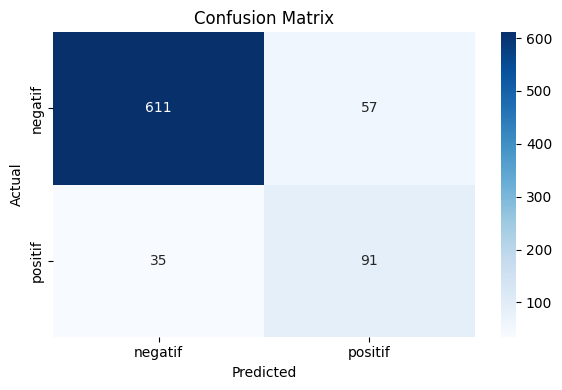

In [10]:
print('Classification report (test):')
print(classification_report(y_test, y_test_pred, digits=4))

labels = sorted(df['label'].unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipeline, df[['text_clean']], df['label'], cv=cv, scoring='accuracy')
print('Cross-validation accuracy per fold:', [round(v, 4) for v in cv_scores])
print('Mean CV accuracy:', round(cv_scores.mean(), 4))

Cross-validation accuracy per fold: [np.float64(0.9005), np.float64(0.9106), np.float64(0.9029), np.float64(0.9206), np.float64(0.8928)]
Mean CV accuracy: 0.9055


In [12]:
sample_texts = [
    'Aplikasinya bagus banget, fiturnya lengkap dan sangat membantu.',
    'Biasa aja, kadang lancar kadang error.',
    'Parah, sering crash dan bikin kecewa.',
]
sample_clean = [preprocess_text(t) for t in sample_texts]
sample_df = pd.DataFrame({'text_clean': sample_clean})
sample_pred = pipeline.predict(sample_df)
sample_lex_score = [lexicon_label(t)[0] for t in sample_clean]

inference_result = pd.DataFrame({
    'teks_asli': sample_texts,
    'teks_preprocessed': sample_clean,
    'skor_lexicon': sample_lex_score,
    'prediksi_sentimen': sample_pred,
})
inference_result

,teks_asli,teks_preprocessed,skor_lexicon,prediksi_sentimen
0,"Aplikasinya bagus banget, fiturnya lengkap dan sangat membantu.",aplikasi bagus banget fiturnya lengkap sangat bantu,-19,negatif
1,"Biasa aja, kadang lancar kadang error.",biasa kadang lancar kadang error,-5,negatif
2,"Parah, sering crash dan bikin kecewa.",parah sering crash bikin kecewa,-6,negatif
